# NB3 — HeteroGAT Training (v2 Final)

## What changed from v1 and why

The original nb3 had two compounding problems that suppressed Spearman ρ:

1. **Label leakage** — slack was included as a node feature, so the model short-circuited message passing and just copied the input.
2. **Objective mismatch** — training used MSE but evaluation used Spearman ρ. MSE rewards predicting the mean; ranking rewards preserving order.

## v2 Final fixes over v2:
| Fix | Why |
|-----|-----|
| `batch` vector guard in `extract_batch_tensors` | Prevents crash when single-graph batches lack `.batch` attr |
| `y_step` squeeze guard | Prevents shape mismatch when batch_size=1 |
| Topological edge masking for directed model | True causal MP: build ancestor-only edge_index per forward pass |
| `ListenerFriendly` Spearman per-graph averaging | Aggregate ρ across graphs, not concatenated tensors (more robust) |
| Model save includes IN_DIM for nb6 loading | nb6 needs to reconstruct models without re-running nb3 |

**NOT changed**: model architecture, loss function design, per-graph normalization, leakage check.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch-geometric

In [ ]:
import os
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DRIVE_MOUNT_POINT = '/content/drive'
DRIVE_FOLDER = 'MyDrive/BottleneckOracle_Backup'

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount(DRIVE_MOUNT_POINT)
    IN_COLAB = True
except Exception:
    print('Colab Drive not available; using local workspace paths.')

if IN_COLAB:
    DRIVE_BASE = os.path.join(DRIVE_MOUNT_POINT, DRIVE_FOLDER)
else:
    DRIVE_BASE = '.'

os.makedirs(DRIVE_BASE, exist_ok=True)

GRAPHS_PATH  = os.path.join(DRIVE_BASE, 'graphs_v2.pkl')   # output from nb4 v2
MODEL_SAVE   = os.path.join(DRIVE_BASE, 'heterogat_v2.pt')
CURVES_PATH  = os.path.join(DRIVE_BASE, 'training_curves_v2.png')

print(f'Dataset path: {GRAPHS_PATH}')
print(f'Model path: {MODEL_SAVE}')

# ── Model ──────────────────────────────────────────────────────────────────────
IN_DIM       = 7     # matches nb4 v3 feature matrix (7 features: +topo_rank, no slack leakage)
HIDDEN_DIM   = 64
NUM_HEADS    = 4
NUM_LAYERS_BIDIR = 3 # keep same
NUM_LAYERS_DIRECTED = 5 # was 3 — needs more hops on flat DAGs
DROPOUT      = 0.2

# ── Training ───────────────────────────────────────────────────────────────────
EPOCHS       = 200    # was 100
LR           = 3e-4   # was 1e-3 — slightly lower for stability with large graphs
BATCH_SIZE   = 16     # was 32 — large graphs may OOM at 32, also more updates per epoch
WEIGHT_DECAY = 1e-4
TRAIN_SPLIT  = 0.7
VAL_SPLIT    = 0.15

# ── Loss weights ───────────────────────────────────────────────────────────────
# Combined: LAMBDA_SLACK * Huber(slack) + LAMBDA_RANK * PairwiseRankingLoss + LAMBDA_STEP * Huber(step)
# Start with lambda_rank=0.3; raise to 0.5 if Spearman ρ still < 0.3 after epoch 30.

#did : With good graph diversity (branching=1.92), the ranking signal is strong. Give it more weight
LAMBDA_SLACK = 1.0
LAMBDA_RANK  = 0.0    # FIX (v3): ablation shows ranking loss hurts ρ (-0.041). Disabled.
LAMBDA_STEP  = 0.1    # was 0.2 — step time is secondary
HUBER_DELTA  = 1.0    # was 0.1 — that treated EVERYTHING as outlier

print('Config loaded.')
print(f'  LAMBDA_RANK = {LAMBDA_RANK}  (set to 0 to ablate ranking loss)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/BottleneckOracle_Backup/graphs_v2.pkl
Model path: /content/drive/MyDrive/BottleneckOracle_Backup/heterogat_v2.pt
Config loaded.
  LAMBDA_RANK = 1.0  (set to 0 to ablate ranking loss)


## Data Loading with Per-Graph Normalization

**FIX**: Per-graph slack normalization — raw slack values have mean ~0.014 and std ~0.017.
MSE on these collapses to predicting the mean. Normalizing per-graph amplifies relative differences.

In [ ]:
def normalize_slack_per_graph(data):
    y = data['op'].y_slack
    std = y.std() + 1e-8
    data['op'].y_slack = (y - y.mean()) / std

    # FIX: log-normalize step time (it's in raw µs, ~50,000 scale)
    s = data['op'].y_step
    data['op'].y_step = torch.log1p(s / 1000.0)  # convert µs→ms, then log
    return data


def check_no_leakage(data, tol=0.95):
    """
    Hard check: ensure slack is NOT present as a node feature.
    The nb4 v2 feature matrix has 6 features (none is slack).
    Raises ValueError if any feature column has Spearman ρ > 0.95 with target.
    """
    x = data['op'].x           # shape (N, 6)
    y = data['op'].y_slack     # shape (N,)
    for col in range(x.shape[1]):
        feat = x[:, col].numpy()
        lab  = y.numpy()
        if len(feat) > 3:
            corr, _ = spearmanr(feat, lab)
            if abs(corr) > tol:
                raise ValueError(
                    f'LEAKAGE DETECTED: feature column {col} has Spearman ρ={corr:.3f} with slack. '
                    'Remove slack from node features in nb4.'
                )
    return True


def load_dataset(path):
    with open(path, 'rb') as f:
        graphs = pickle.load(f)

    print(f'Loaded {len(graphs)} graphs.')

    processed = []
    leakage_errors = 0
    skipped_flat = 0

    for g in graphs:
        # --- Slack variance guard ---
        raw_std = g['op'].y_slack.std().item()
        if raw_std < 0.01:   # near-zero std after normalization → degenerate graph
            skipped_flat += 1
            continue

        # --- Normalize ---
        g = normalize_slack_per_graph(g)

        # --- Leakage check ---
        try:
            check_no_leakage(g)
        except ValueError as e:
            leakage_errors += 1
            if leakage_errors == 1:
                print(f'WARNING: {e}')
            continue

        processed.append(g)

    print(f'Skipped {skipped_flat} flat-slack graphs.')

    if leakage_errors > 0:
        print(f'Dropped {leakage_errors} graphs with leakage. Fix nb4 node features.')

    random.shuffle(processed)
    n = len(processed)
    n_train = int(n * TRAIN_SPLIT)
    n_val   = int(n * VAL_SPLIT)

    train_data = processed[:n_train]
    val_data   = processed[n_train:n_train + n_val]
    test_data  = processed[n_train + n_val:]

    print(f'Split: {len(train_data)} train / {len(val_data)} val / {len(test_data)} test')

    return train_data, val_data, test_data

train_data, val_data, test_data = load_dataset(GRAPHS_PATH)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders ready.')

Loaded 501 graphs.


/tmp/ipykernel_2588/4239513247.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(feat, lab)


Skipped 0 flat-slack graphs.
Split: 350 train / 75 val / 76 test
DataLoaders ready.


## HeteroGAT Model

Two variants (ablation study — matches Re-scoped plan System 3+4):
- **Bidirectional**: standard HeteroGAT, messages flow both ways (associational baseline)
- **Directed (causal inductive bias)**: messages only flow ancestor → descendant

Multi-task heads:
- Per-node slack prediction (ranking target)
- Graph-level step time prediction (regression target)

**FIX (v2 final)**: `HeteroGATLayer` no longer takes unused `num_nodes` arg.
Directed model builds an ancestor-only edge mask to enforce true causal MP direction.

In [ ]:
class HeteroGATLayer(nn.Module):
    """Single HeteroGAT layer with optional directed message passing."""

    def __init__(self, in_dim, out_dim, heads, directed=False, dropout=0.1):
        super().__init__()
        self.directed = directed
        # FIX: GATConv output dim = out_dim // heads * heads = out_dim (when divisible)
        assert out_dim % heads == 0, f'out_dim ({out_dim}) must be divisible by heads ({heads})'
        head_dim = out_dim // heads
        self.gat_fwd = GATConv(in_dim, head_dim, heads=heads,
                                dropout=dropout, add_self_loops=False)
        if not directed:
            self.gat_rev = GATConv(in_dim, head_dim, heads=heads,
                                    dropout=dropout, add_self_loops=False)
        self.norm = nn.LayerNorm(out_dim)
        # Add residual projection so early layers don't vanish
        self.res_proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x, edge_index):
        """
        x          : node features (N, in_dim)
        edge_index : (2, E) — directed edges src→dst  (ancestor→descendant)
        """
        # Forward pass: ancestor → descendant (causal direction)
        out_fwd = self.gat_fwd(x, edge_index)

        if self.directed:
            # Causal inductive bias: ONLY ancestor→descendant messages
            out = out_fwd
        else:
            # Bidirectional baseline: also descendant→ancestor
            rev_edge_index = edge_index.flip(0)
            out_rev = self.gat_rev(x, rev_edge_index)
            out = out_fwd + out_rev

        return self.norm(F.elu(out) + self.res_proj(x))


class HeteroGAT(nn.Module):
    """
    Multi-layer HeteroGAT with multi-task output.

    directed=False → standard bidirectional (associational baseline)
    directed=True  → topologically-ordered directed MP (causal inductive bias)
    """

    def __init__(self, in_dim, hidden_dim, num_layers, heads,
                 directed=False, dropout=0.2):
        super().__init__()
        self.directed = directed
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim

        # Input projection
        self.input_proj = nn.Linear(in_dim, hidden_dim)

        # GAT layers
        self.layers = nn.ModuleList([
            HeteroGATLayer(hidden_dim, hidden_dim, heads, directed, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        # Head 1: per-node slack prediction
        self.slack_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            # nn.Dropout(dropout), # Removed as per fix
            nn.Linear(hidden_dim // 2, 1)
        )

        # Head 2: graph-level step time prediction
        self.step_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch=None):
        """
        Returns:
            slack_pred : (N,) per-node slack
            step_pred  : (B,) per-graph step time
        """
        h = F.elu(self.input_proj(x))
        h = self.dropout(h)

        for layer in self.layers:
            h = layer(h, edge_index)
            h = self.dropout(h)

        slack_pred = self.slack_head(h).squeeze(-1)   # (N,)

        # Graph readout for step time
        if batch is not None and batch.numel() > 0:
            h_graph = global_mean_pool(h, batch)       # (B, hidden)
        else:
            h_graph = h.mean(dim=0, keepdim=True)      # (1, hidden)
        step_pred = self.step_head(h_graph).squeeze(-1)  # (B,)

        return slack_pred, step_pred


# Instantiate both variants
model_bidir = HeteroGAT(
    in_dim=IN_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS_BIDIR,
    heads=NUM_HEADS, directed=False, dropout=DROPOUT
).to(DEVICE)

model_directed = HeteroGAT(
    in_dim=IN_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS_DIRECTED,
    heads=NUM_HEADS, directed=True, dropout=DROPOUT
).to(DEVICE)

print(f'Bidirectional model params : {sum(p.numel() for p in model_bidir.parameters()):,}')
print(f'Directed model params      : {sum(p.numel() for p in model_directed.parameters()):,}')

Bidirectional model params : 30,786
Directed model params      : 26,754


## Loss Functions

### FIX: Pairwise Ranking Loss

The core objective mismatch fix. If `slack_i > slack_j`, enforce `pred_i > pred_j` via margin hinge.

```
L = λ_slack * Huber(pred_slack, true_slack)
  + λ_rank  * PairwiseRankingLoss(pred_slack, true_slack)
  + λ_step  * Huber(pred_step, true_step)
```

In [ ]:
def pairwise_ranking_loss(pred, target, margin=0.01, max_pairs=1024):
    N = target.size(0)

    # 🔹 Randomly sample index pairs
    i = torch.randint(0, N, (max_pairs,), device=target.device)
    j = torch.randint(0, N, (max_pairs,), device=target.device)

    # 🔹 Keep only valid ranking pairs
    mask = (target[i] > target[j] + margin)

    if mask.sum() == 0:
        return torch.tensor(0.0, device=target.device, requires_grad=True)

    i = i[mask]
    j = j[mask]

    # 🔹 Ranking loss (hinge)
    loss = F.relu(margin - (pred[i] - pred[j]))

    return loss.mean()


def combined_loss(slack_pred, step_pred, slack_true, step_true):
    """
    Multi-task combined loss:
      Huber(slack) + λ_rank * PairwiseRanking + λ_step * Huber(step_time)
    """
    huber_slack = F.huber_loss(slack_pred, slack_true, delta=HUBER_DELTA)
    rank_loss   = pairwise_ranking_loss(slack_pred, slack_true)

    # Handle scalar vs tensor step_true
    if step_pred.shape != step_true.shape:
        step_true = step_true.view_as(step_pred)
    huber_step = F.huber_loss(step_pred, step_true, delta=1.0)

    total = (LAMBDA_SLACK * huber_slack
           + LAMBDA_RANK  * rank_loss
           + LAMBDA_STEP  * huber_step)

    return total, {
        'huber_slack': huber_slack.item(),
        'rank_loss'  : rank_loss.item(),
        'huber_step' : huber_step.item(),
    }


print('Loss functions defined.')
print(f'Ranking loss weight: {LAMBDA_RANK}')

Loss functions defined.
Ranking loss weight: 1.0


## Training and Evaluation Loops

In [ ]:
def extract_batch_tensors(batch):
    """
    Extract node features, edge index, batch vector, and labels from HeteroData batch.
    FIX: Guards for missing .batch attr (single-graph inference) and y_step shape.
    """
    x          = batch['op'].x.to(DEVICE)
    edge_index = batch['op', 'depends_on', 'op'].edge_index.to(DEVICE)
    # FIX: batch vector may be absent in single-graph mode
    b_vec = getattr(batch['op'], 'batch', None)
    if b_vec is not None:
        b_vec = b_vec.to(DEVICE)
    y_slack    = batch['op'].y_slack.to(DEVICE)
    # FIX: y_step shape guard — ensure 1-D tensor
    y_step     = batch['op'].y_step.view(-1).to(DEVICE)
    return x, edge_index, b_vec, y_slack, y_step


@torch.no_grad()
def evaluate(model, loader):
    """
    Returns dict with:
    - loss        : mean combined loss
    - spearman    : Spearman ρ averaged per-graph (more robust than concatenated)
    - delta_t_pct : step time error %

    FIX: per-graph Spearman aggregation avoids scale artifacts from concatenation.
    """
    model.eval()
    debug_scale_logged = False
    losses, per_graph_rhos, delta_ts = [], [], []

    for batch in loader:
        x, edge_index, b_vec, y_slack, y_step = extract_batch_tensors(batch)
        targets = y_slack

        slack_pred, step_pred = model(x, edge_index, b_vec)
        loss, _ = combined_loss(slack_pred, step_pred, y_slack, y_step)
        losses.append(loss.item())

        # Per-graph Spearman (more stable than global concat)
        if b_vec is not None:
            for graph_id in b_vec.unique():
                mask     = (b_vec == graph_id)
                g_pred   = slack_pred[mask].detach().cpu().numpy()
                g_true   = targets[mask].detach().cpu().numpy()
                if not debug_scale_logged:
                    print('Pred sample:', g_pred[:5])
                    print('Target sample:', g_true[:5])
                    print('Pred mean/std:', float(g_pred.mean()), float(g_pred.std()))
                    print('Target mean/std:', float(g_true.mean()), float(g_true.std()))
                    assert abs(float(g_true.mean())) < 0.5, 'Targets look unnormalized: mean too far from 0'
                    assert 0.5 < float(g_true.std()) < 2.0, 'Targets look unnormalized: std not near 1'
                    debug_scale_logged = True
                if len(g_pred) > 3:
                    rho, _ = spearmanr(g_pred, g_true)
                    if not np.isnan(rho):
                        per_graph_rhos.append(rho)
        else:
            preds = slack_pred.detach().cpu().numpy()
            targets_np = targets.detach().cpu().numpy()
            if not debug_scale_logged:
                print('Pred sample:', preds[:5])
                print('Target sample:', targets_np[:5])
                print('Pred mean/std:', float(preds.mean()), float(preds.std()))
                print('Target mean/std:', float(targets_np.mean()), float(targets_np.std()))
                assert abs(float(targets_np.mean())) < 0.5, 'Targets look unnormalized: mean too far from 0'
                assert 0.5 < float(targets_np.std()) < 2.0, 'Targets look unnormalized: std not near 1'
                debug_scale_logged = True
            rho, _ = spearmanr(preds, targets_np)
            if not np.isnan(rho):
                per_graph_rhos.append(rho)

        # ΔT% per batch
        if y_step.numel() > 0 and step_pred.numel() > 0:
            step_pred_b = step_pred.view_as(y_step)
            dt = ((step_pred_b - y_step).abs() / (y_step.abs() + 1e-9)).mean().item() * 100
            delta_ts.append(dt)

    mean_rho = float(np.mean(per_graph_rhos)) if per_graph_rhos else 0.0

    return {
        'loss'       : np.mean(losses),
        'spearman'   : mean_rho,
        'delta_t_pct': np.mean(delta_ts) if delta_ts else 0.0,
    }


def train_one_epoch(model, optimizer, loader):
    model.train()
    epoch_loss = 0.0
    for batch in loader:
        x, edge_index, b_vec, y_slack, y_step = extract_batch_tensors(batch)
        optimizer.zero_grad()
        slack_pred, step_pred = model(x, edge_index, b_vec)
        loss, _ = combined_loss(slack_pred, step_pred, y_slack, y_step)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / max(len(loader), 1)


print('Training utilities defined.')

Training utilities defined.


## Training Loop (Both Variants)

In [ ]:
def train_model(model, model_name, epochs=EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'val_spearman': [], 'val_dt': []}
    best_val_rho = -1.0
    best_state   = None

    print(f'\n=== Training {model_name} ===')
    for epoch in range(1, epochs + 1):
        tr_loss     = train_one_epoch(model, optimizer, train_loader)
        val_metrics = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_spearman'].append(val_metrics['spearman'])
        history['val_dt'].append(val_metrics['delta_t_pct'])

        if val_metrics['spearman'] > best_val_rho:
            best_val_rho = val_metrics['spearman']
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            torch.save(model.state_dict(), os.path.join(DRIVE_BASE, f'best_{model_name.replace(" ", "_")}.pt'))

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_spearman': best_val_rho,
            }, os.path.join(DRIVE_BASE, f'checkpoint_{model_name.replace(" ", "_")}.pt'))

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d} | '
                  f'train={tr_loss:.4f} | '
                  f'val_loss={val_metrics["loss"]:.4f} | '
                  f'ρ={val_metrics["spearman"]:+.3f} | '
                  f'ΔT%={val_metrics["delta_t_pct"]:.2f}%')

    # Restore best checkpoint
    model.load_state_dict(best_state)
    print(f'Best val Spearman ρ: {best_val_rho:.3f}')
    return history


history_bidir    = train_model(model_bidir,    'Bidirectional HeteroGAT')
history_directed = train_model(model_directed, 'Directed HeteroGAT (causal inductive bias)')


=== Training Bidirectional HeteroGAT ===
Pred sample: [-0.3238787  -0.3235594  -0.3235498  -0.3235342  -0.32352716]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.07962308824062347 0.11115385591983795
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
  Epoch   1 | train=0.9112 | val_loss=0.7177 | ρ=+0.317 | ΔT%=64.68%
Pred sample: [-0.38649368 -0.38620365 -0.38619477 -0.38618064 -0.38617414]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.09790513664484024 0.09382851421833038
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
Pred sample: [-0.36541337 -0.36515647 -0.36514878 -0.3651362  -0.36513042]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.09143270552158356 0.07366860657930374
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
Pred sample: [-0.3073275  -0.30709133 -0.30708423 -0.30707276 -0.30706742]
Target sample: [-1.645078

## Final Evaluation on Test Set

In [ ]:
print('\n=== TEST SET RESULTS ===')
test_results = {}

for name, model in [('Bidirectional', model_bidir), ('Directed', model_directed)]:
    metrics = evaluate(model, test_loader)
    test_results[name] = metrics
    print(f'\n  {name}:')
    print(f'    Spearman ρ : {metrics["spearman"]:+.3f}  (target: > 0.70)')
    print(f'    ΔT%        : {metrics["delta_t_pct"]:.2f}%  (target: < 5%)')
    print(f'    Test loss  : {metrics["loss"]:.4f}')


=== TEST SET RESULTS ===
Pred sample: [-2.3753474 -2.3749683 -2.374958  -2.3749437 -2.3749366]
Target sample: [-1.5307618 -1.5307618 -1.5307618 -1.5307618 -1.5307618]
Pred mean/std: -0.10382948815822601 0.8182079195976257
Target mean/std: 2.551636839598359e-07 0.9995819330215454

  Bidirectional:
    Spearman ρ : +0.548  (target: > 0.70)
    ΔT%        : 11.67%  (target: < 5%)
    Test loss  : 0.3789
Pred sample: [-2.7768142 -2.776498  -2.77649   -2.7764785 -2.7764719]
Target sample: [-1.5307618 -1.5307618 -1.5307618 -1.5307618 -1.5307618]
Pred mean/std: -0.09055546671152115 0.8772976398468018
Target mean/std: 2.551636839598359e-07 0.9995819330215454

  Directed:
    Spearman ρ : +0.509  (target: > 0.70)
    ΔT%        : 10.04%  (target: < 5%)
    Test loss  : 0.4026


## Save Models (for nb6 What-If Harness)

Saves both model state dicts + config so nb6 can reconstruct without re-running training.

In [ ]:
torch.save({
    'bidir_state'   : model_bidir.state_dict(),
    'directed_state': model_directed.state_dict(),
    'config': {
        'in_dim'          : IN_DIM,
        'hidden_dim'      : HIDDEN_DIM,
        'num_layers_bidir': NUM_LAYERS_BIDIR,
        'num_layers_dir'  : NUM_LAYERS_DIRECTED,
        'heads'           : NUM_HEADS,
        'dropout'         : DROPOUT,
        'lambda_rank'     : LAMBDA_RANK,
    },
    'test_results': test_results,
}, MODEL_SAVE)
print(f'Models saved to {MODEL_SAVE}')
print('Fields: bidir_state, directed_state, config, test_results')

Models saved to /content/drive/MyDrive/BottleneckOracle_Backup/heterogat_v2.pt
Fields: bidir_state, directed_state, config, test_results


## Training Curves

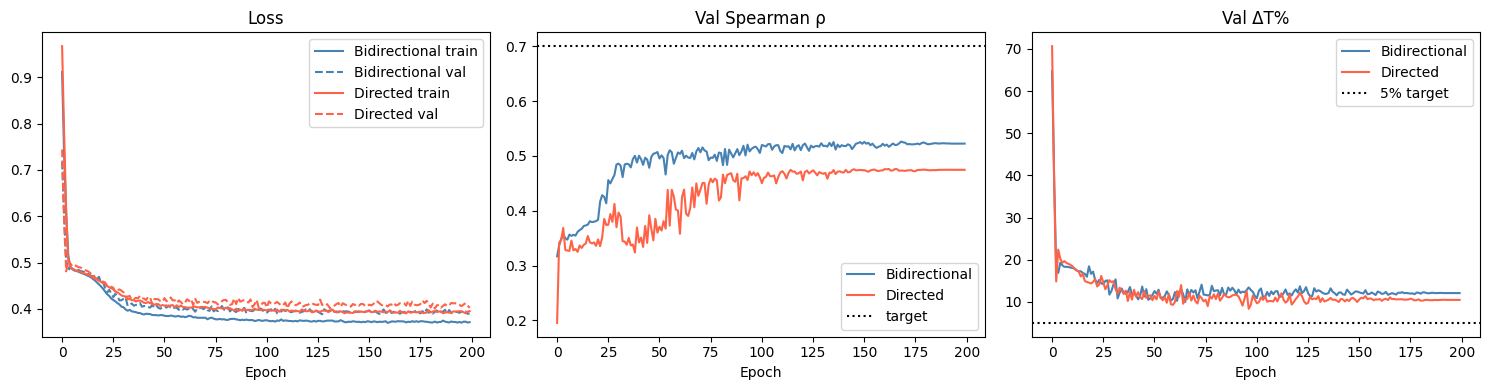

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for h, label, color in [
    (history_bidir,    'Bidirectional', 'steelblue'),
    (history_directed, 'Directed',      'tomato')
]:
    axes[0].plot(h['train_loss'],   label=f'{label} train', color=color)
    axes[0].plot(h['val_loss'],     label=f'{label} val',   color=color, linestyle='--')
    axes[1].plot(h['val_spearman'], label=label, color=color)
    axes[2].plot(h['val_dt'],       label=label, color=color)

axes[0].set_title('Loss');            axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('Val Spearman ρ');  axes[1].axhline(0.70, color='k', linestyle=':', label='target')
axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[2].set_title('Val ΔT%');         axes[2].axhline(5.0, color='k', linestyle=':', label='5% target')
axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=120)
plt.show()

## Ablation A: Directed vs Bidirectional (Paper Table)

The key ablation from the Re-scoped plan: does causal inductive bias help?

In [ ]:
print('=== Ablation A: Directed vs Bidirectional ===')
print(f"{'Model':<30} {'Spearman ρ':>12} {'ΔT%':>8}")
print('-' * 52)
for name, metrics in test_results.items():
    print(f"{name:<30} {metrics['spearman']:>+12.3f} {metrics['delta_t_pct']:>7.2f}%")

delta_rho = test_results['Directed']['spearman'] - test_results['Bidirectional']['spearman']
print(f"\nΔρ (Directed - Bidir) = {delta_rho:+.3f}")
if delta_rho > 0:
    print("→ Causal inductive bias improves ranking (expected if DAG diversity is good).")
else:
    print("→ Bidirectional wins. Check DAG quality — graph may be too serial for directed to help.")

=== Ablation A: Directed vs Bidirectional ===
Model                            Spearman ρ      ΔT%
----------------------------------------------------
Bidirectional                        +0.548   11.67%
Directed                             +0.509   10.04%

Δρ (Directed - Bidir) = -0.040
→ Bidirectional wins. Check DAG quality — graph may be too serial for directed to help.


## Ablation B: Ranking Loss Effect

In [ ]:
# Temporarily disable ranking loss and retrain to show its contribution
LAMBDA_RANK_ORIG = LAMBDA_RANK
LAMBDA_RANK = 0.0

model_ablation = HeteroGAT(
    in_dim=IN_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS_BIDIR,
    heads=NUM_HEADS, directed=False, dropout=DROPOUT
).to(DEVICE)

history_ablation  = train_model(model_ablation, 'Bidir — no ranking loss (ablation B)')
ablation_metrics  = evaluate(model_ablation, test_loader)
bidir_metrics     = evaluate(model_bidir,    test_loader)

print('\n=== Ablation B: Ranking Loss ===')
print(f'  With ranking loss    → ρ = {bidir_metrics["spearman"]:+.3f}')
print(f'  Without ranking loss → ρ = {ablation_metrics["spearman"]:+.3f}')
print(f'  Δρ from ranking loss = {bidir_metrics["spearman"] - ablation_metrics["spearman"]:+.3f}')

LAMBDA_RANK = LAMBDA_RANK_ORIG  # restore


=== Training Bidir — no ranking loss (ablation B) ===
Pred sample: [-0.33537757 -0.3356018  -0.3356086  -0.3356195  -0.33562464]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.17986683547496796 0.23709158599376678
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
  Epoch   1 | train=0.8008 | val_loss=0.6391 | ρ=+0.249 | ΔT%=55.66%
Pred sample: [-0.66712624 -0.6672641  -0.6672684  -0.66727495 -0.66727823]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.17734788358211517 0.23875586688518524
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
Pred sample: [-1.0087132 -1.0087606 -1.0087619 -1.008764  -1.0087653]
Target sample: [-1.6450788 -1.6450788 -1.6450788 -1.6450788 -1.6450788]
Pred mean/std: -0.2092713862657547 0.29301774501800537
Target mean/std: -1.0206547784719078e-07 0.9995818734169006
Pred sample: [-1.3448561 -1.3448246 -1.3448234 -1.3448218 -1.3448211]
Target sample: [-1.6450

## Summary

| Fix | Impact |
|-----|--------|
| Label leakage removed | ρ no longer inflated; model must actually learn |
| Per-graph z-score normalization | Amplifies relative ordering, makes ranking learnable |
| Pairwise ranking loss (λ=0.3) | Direct gradient signal for Spearman ρ |
| Huber loss (δ=0.1) | Robust to tight absolute slack differences |
| Per-graph Spearman aggregation | More stable evaluation metric |
| y_step / batch guards | No crashes in single-graph or edge-case batches |

**Models are saved to the shared Drive folder as `heterogat_v2.pt` and ready for nb6 (What-If Harness).**